# Proyecto: Bank Marketing Campaign

## Clasificación con Regresión Logística

### Descripción del problema

Un banco portugués está experimentando una disminución en sus ingresos y desea identificar a los clientes existentes con mayor probabilidad de contratar un depósito a largo plazo.

El objetivo es construir un modelo de clasificación que permita predecir si un cliente contratará (yes) o no (no) el depósito.

El proyecto se desarrollará siguiendo cuatro pasos:

1. Carga del conjunto de datos.
2. Análisis exploratorio de datos (EDA).
3. Construcción de un modelo de regresión logística.
4. Optimización básica del modelo.

In [9]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme()

# Paso 1: Carga del conjunto de datos

Primero cargaremos el archivo directamente desde la URL proporcionada.

In [10]:

df = pd.read_csv(u"https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Normalización de nombres de columnas

In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(".", "_", regex=False)
)

df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed',
 'y']

# Paso 2: Análisis Exploratorio de Datos (EDA)

El EDA permite comprender la estructura, calidad y comportamiento de los datos antes de construir el modelo.

## 2.1 Exploración inicial

In [12]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

display(df.head())
display(df.dtypes)
df.info()

Número de filas: 41188
Número de columnas: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp_var_rate      float64
cons_price_idx    float64
cons_conf_idx     float64
euribor3m         float64
nr_employed       float64
y                     str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null  float64
 1

## 2.2 Valores faltantes

In [13]:
missing = pd.DataFrame({
    "cantidad": df.isnull().sum(),
    "porcentaje": (df.isnull().mean() * 100).round(2)
})

missing.sort_values("porcentaje", ascending=False)

,cantidad,porcentaje
age,0,0.0
campaign,0,0.0
nr_employed,0,0.0
euribor3m,0,0.0
cons_conf_idx,0,0.0
cons_price_idx,0,0.0
emp_var_rate,0,0.0
poutcome,0,0.0
previous,0,0.0
pdays,0,0.0


## Revisión de categorías unknown

In [14]:
categorical_columns_all = df.select_dtypes(include="object").columns.tolist()

unknown_counts = {}

for columna in categorical_columns_all:
    unknown_counts[columna] = (
        df[columna]
        .astype(str)
        .str.lower()
        .eq("unknown")
        .sum()
    )

pd.Series(
    unknown_counts,
    name="cantidad_unknown"
).sort_values(ascending=False)

default        8597
education      1731
housing         990
loan            990
job             330
marital          80
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
Name: cantidad_unknown, dtype: int64

## 2.3 Duplicados

In [15]:
duplicados = df.duplicated().sum()

print("Cantidad de filas duplicadas:", duplicados)
print(
    "Porcentaje de duplicados:",
    round((duplicados / len(df)) * 100, 2),
    "%"
)

Cantidad de filas duplicadas: 12
Porcentaje de duplicados: 0.03 %


In [16]:
duplicados_df = df[df.duplicated(keep=False)]
duplicados_df.head(20)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [17]:
df = df.drop_duplicates().copy()

print("Dimensiones después de eliminar duplicados:", df.shape)

Dimensiones después de eliminar duplicados: (41176, 21)


## 2.4 Variables numéricas y categóricas

In [18]:
numerical_columns = df.select_dtypes(include="number").columns.tolist()

categorical_columns = (
    df.select_dtypes(include="object")
    .columns
    .drop("y")
    .tolist()
)

print("Variables numéricas:")
print(numerical_columns)

print("\nVariables categóricas:")
print(categorical_columns)

Variables numéricas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 2.5 Variable objetivo

In [19]:
print(df["y"].value_counts())

print("\nPorcentajes:")
print(
    (df["y"].value_counts(normalize=True) * 100).round(2)
)

y
no     36537
yes     4639
Name: count, dtype: int64

Porcentajes:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


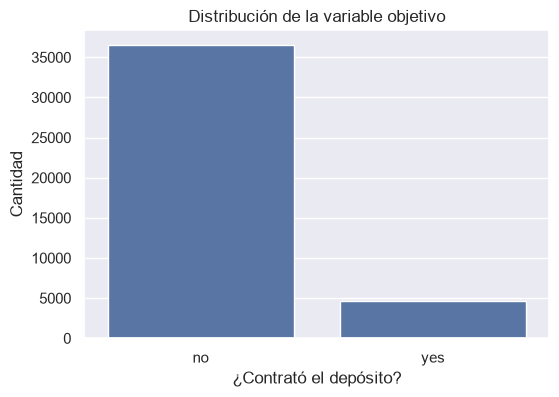

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="y"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("¿Contrató el depósito?")
plt.ylabel("Cantidad")
plt.show()

## 2.6 Análisis univariante de variables numéricas

In [21]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp_var_rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons_price_idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons_conf_idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr_employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


### Histogramas y boxplots

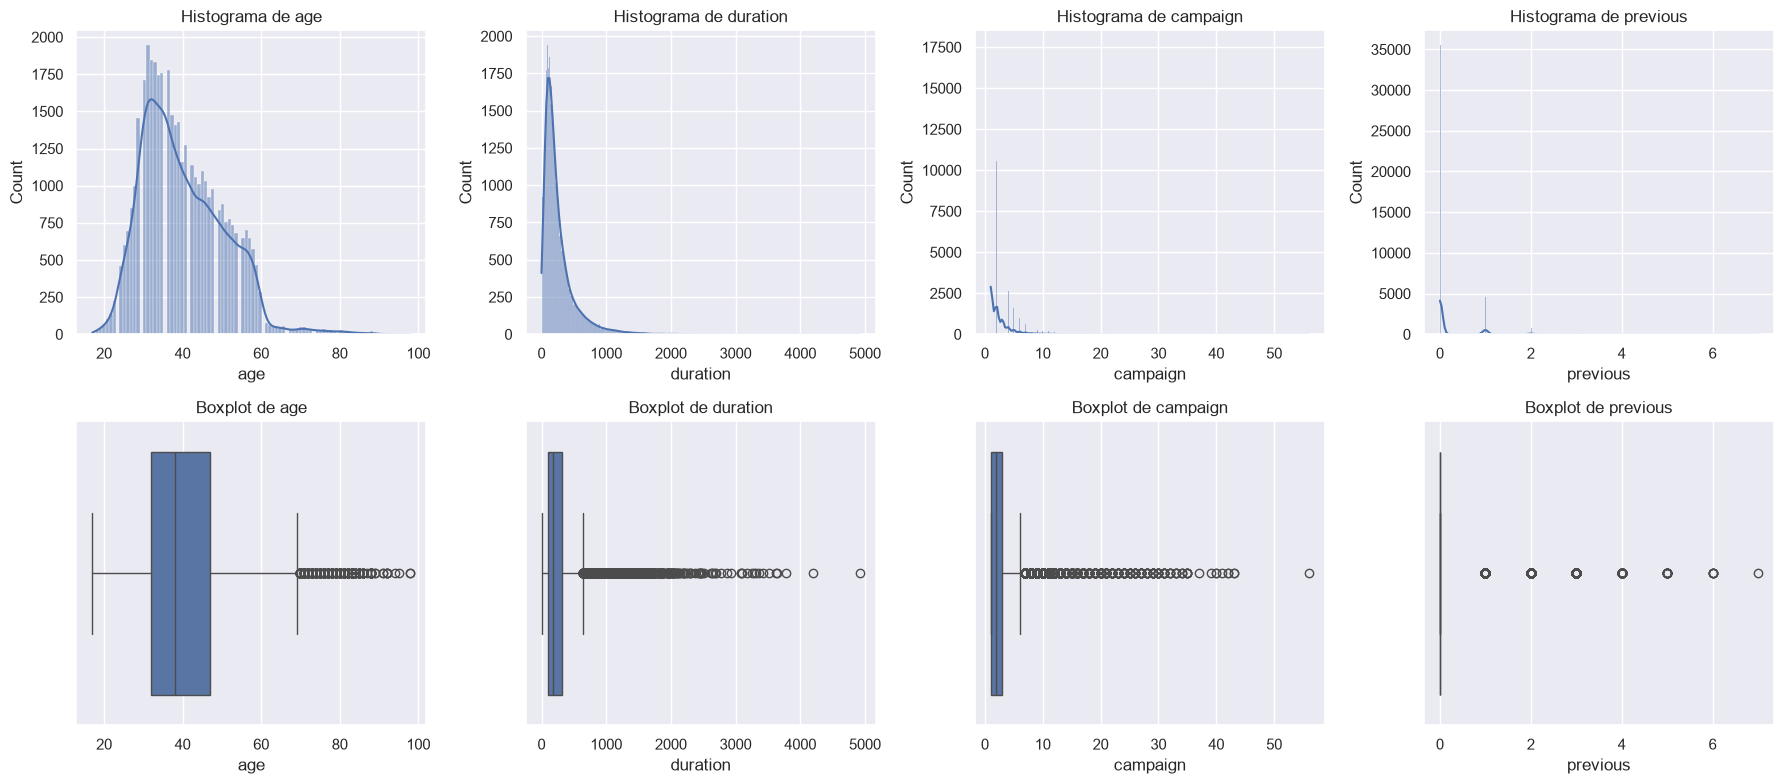

In [22]:
variables_distribucion = [
    "age",
    "duration",
    "campaign",
    "previous"
]

fig, axes = plt.subplots(
    2,
    len(variables_distribucion),
    figsize=(18, 8)
)

for col, variable in enumerate(variables_distribucion):

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        ax=axes[0, col]
    )
    axes[0, col].set_title(f"Histograma de {variable}")

    sns.boxplot(
        data=df,
        x=variable,
        ax=axes[1, col]
    )
    axes[1, col].set_title(f"Boxplot de {variable}")

plt.tight_layout()
plt.show()

Los histogramas permiten observar la forma de la distribución y los boxplots ayudan a identificar dispersión y posibles valores extremos.

## 2.7 Revisión especial de pdays

In [23]:
df["pdays"].value_counts().head(10)

pdays
999    39661
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
Name: count, dtype: int64

El valor `999` se utiliza habitualmente para representar que el cliente no había sido contactado previamente.

## 2.8 Análisis univariante de variables categóricas

In [24]:
top_n = 15

for columna in categorical_columns:

    conteo = df[columna].value_counts().head(top_n)

    porcentaje = (
        df[columna]
        .value_counts(normalize=True)
        .head(top_n) * 100
    )

    tabla = pd.DataFrame({
        "cantidad": conteo,
        "porcentaje": porcentaje.round(2)
    })

    print(f"\nVariable: {columna}")
    display(tabla)


Variable: job


,cantidad,porcentaje
job,,
admin.,10419,25.30
blue-collar,9253,22.47
technician,6739,16.37
services,3967,9.63
management,2924,7.10
retired,1718,4.17
entrepreneur,1456,3.54
self-employed,1421,3.45
housemaid,1060,2.57



Variable: marital


,cantidad,porcentaje
marital,,
married,24921,60.52
single,11564,28.08
divorced,4611,11.20
unknown,80,0.19



Variable: education


...

,cantidad,porcentaje
month,,
may,13767,33.43
jul,7169,17.41
aug,6176,15.00
jun,5318,12.92
nov,4100,9.96
apr,2631,6.39
oct,717,1.74
sep,570,1.38
mar,546,1.33



Variable: day_of_week


,cantidad,porcentaje
day_of_week,,
thu,8618,20.93
mon,8512,20.67
wed,8134,19.75
tue,8086,19.64
fri,7826,19.01



Variable: poutcome


,cantidad,porcentaje
poutcome,,
nonexistent,35551,86.34
failure,4252,10.33
success,1373,3.33


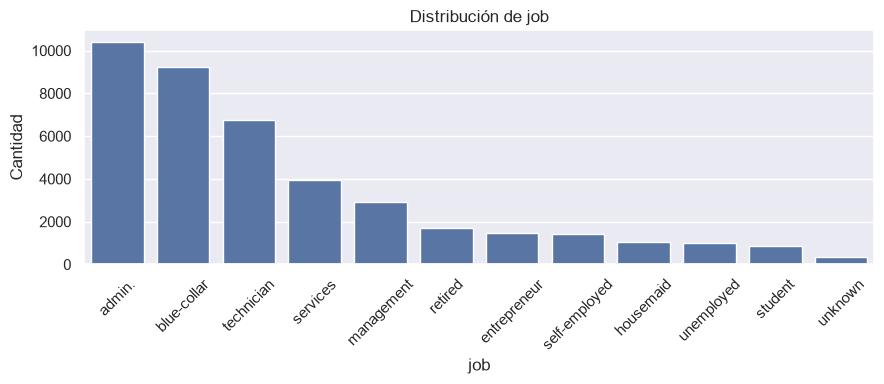

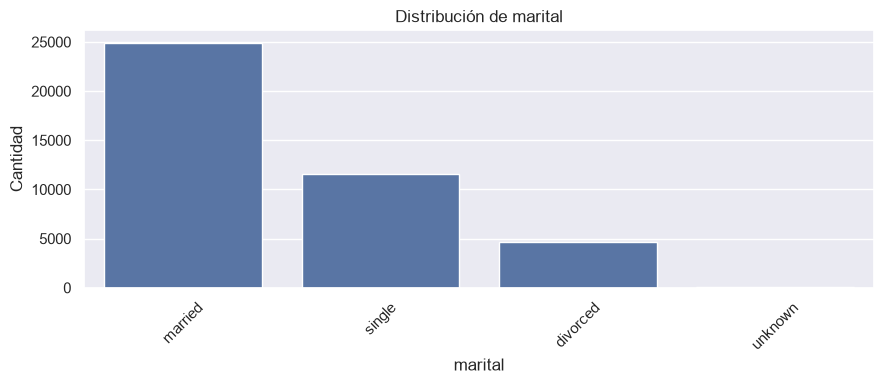

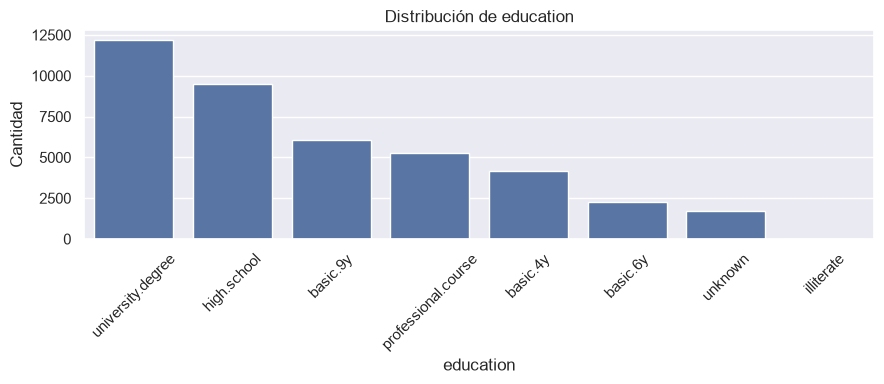

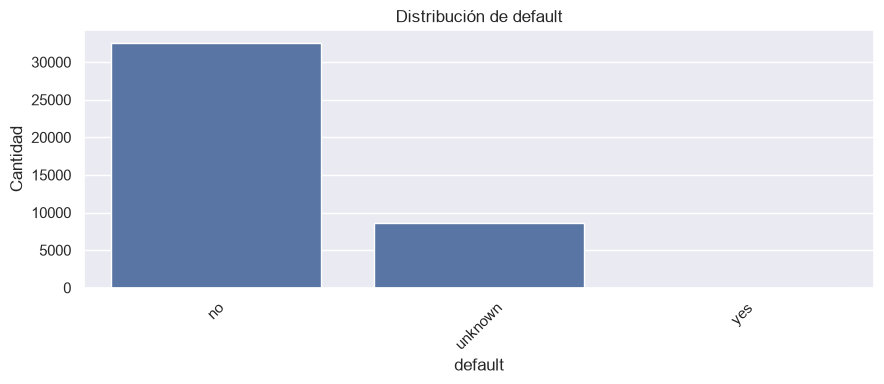

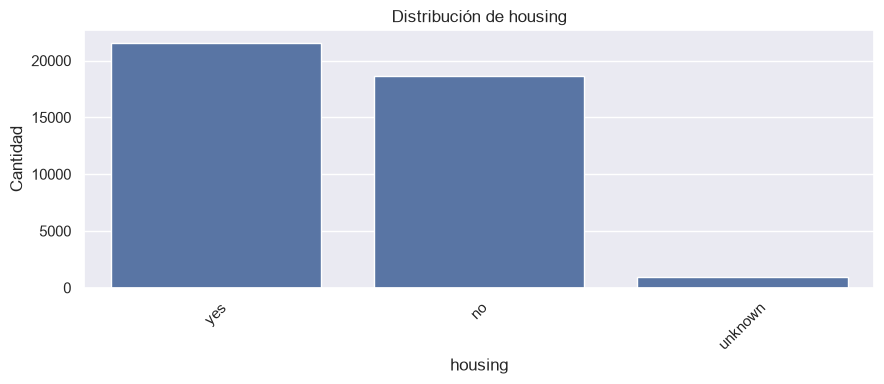

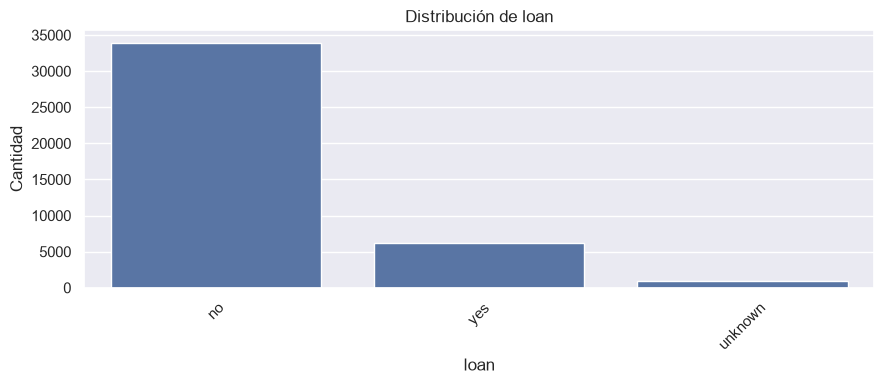

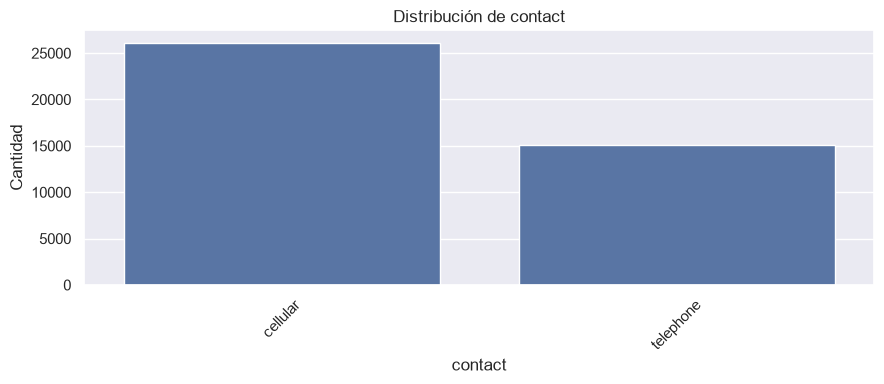

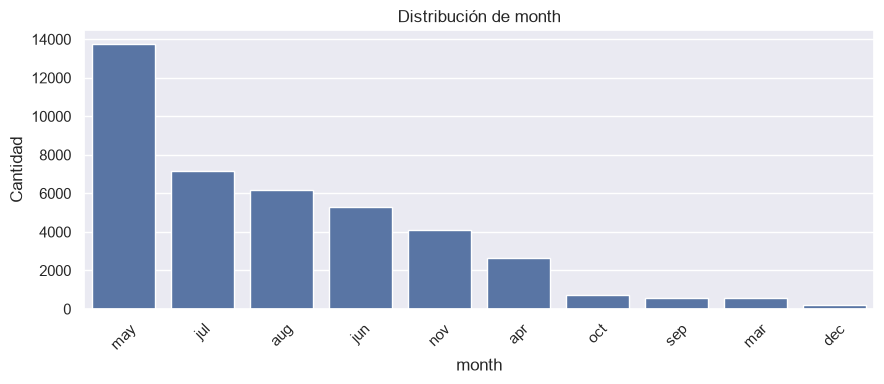

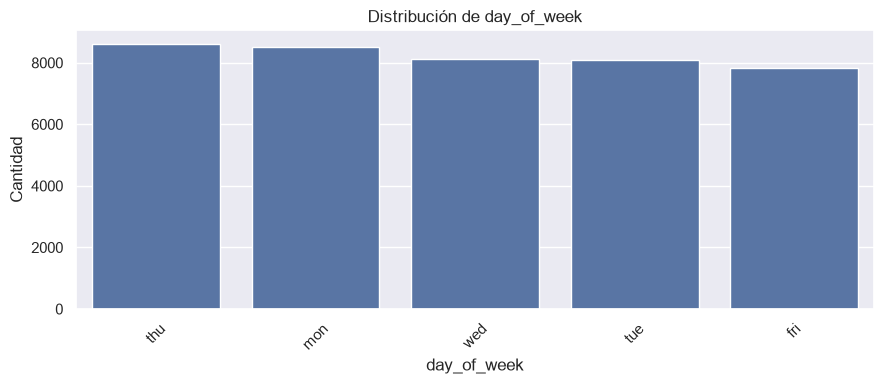

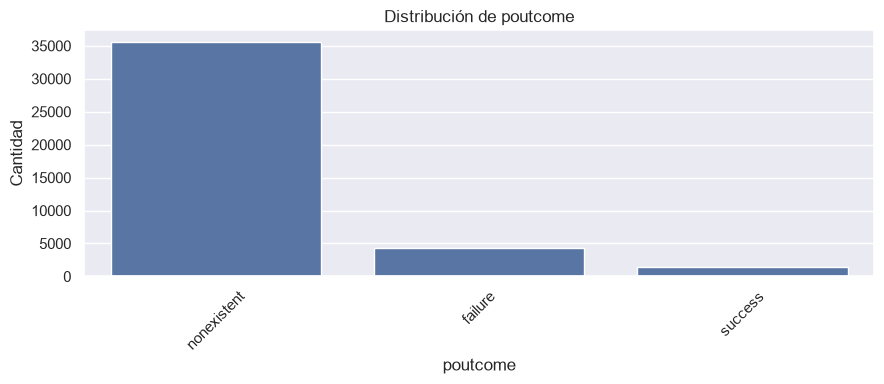

In [25]:
for columna in categorical_columns:

    plt.figure(figsize=(9, 4))

    order = df[columna].value_counts().index

    sns.countplot(
        data=df,
        x=columna,
        order=order
    )

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Cantidad")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 2.9 Análisis multivariante

### Conversión temporal de la variable objetivo

In [26]:
df["target"] = df["y"].map({
    "no": 0,
    "yes": 1
})

df[["y", "target"]].head()

,y,target
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


### Variables numéricas vs. objetivo

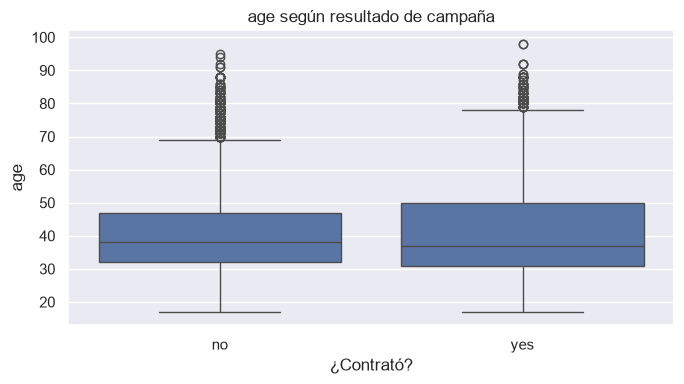

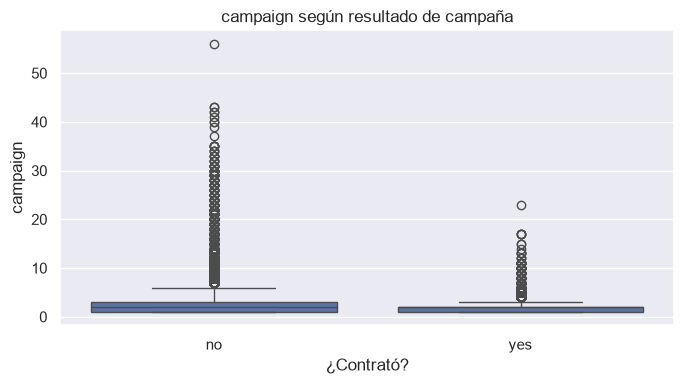

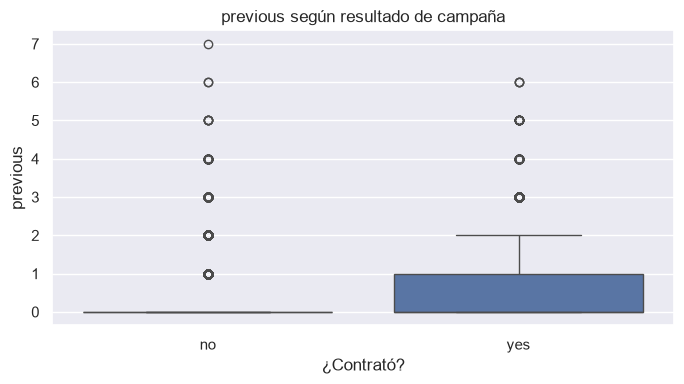

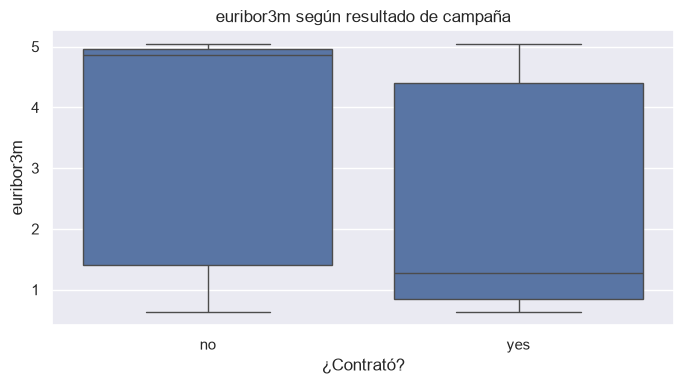

In [27]:
for columna in ["age", "campaign", "previous", "euribor3m"]:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="y",
        y=columna
    )

    plt.title(f"{columna} según resultado de campaña")
    plt.xlabel("¿Contrató?")
    plt.ylabel(columna)
    plt.tight_layout()
    plt.show()

### Variables categóricas vs. objetivo

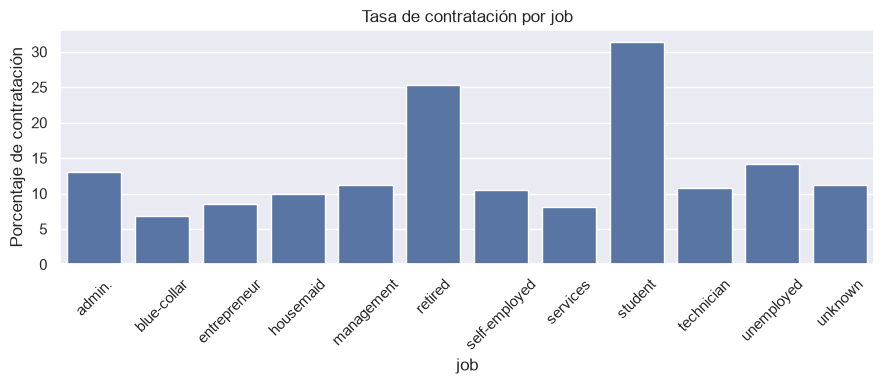

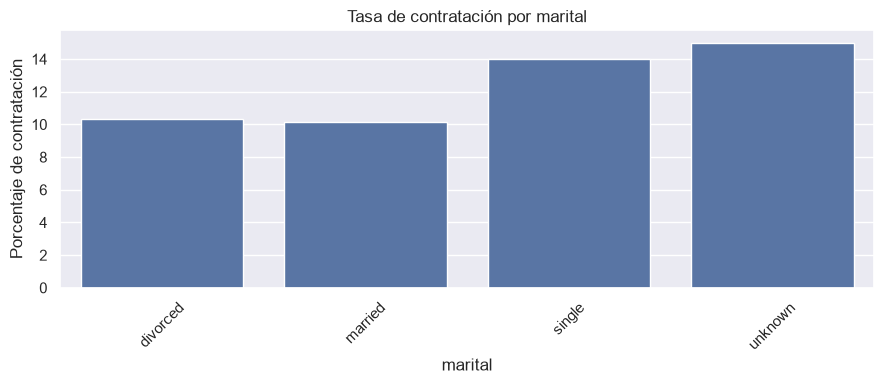

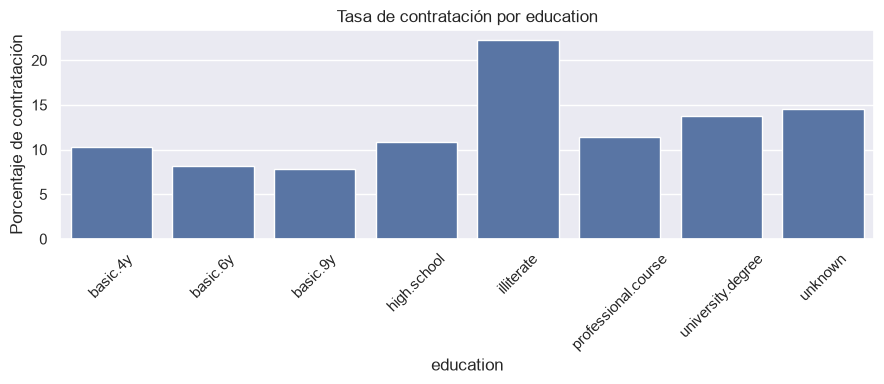

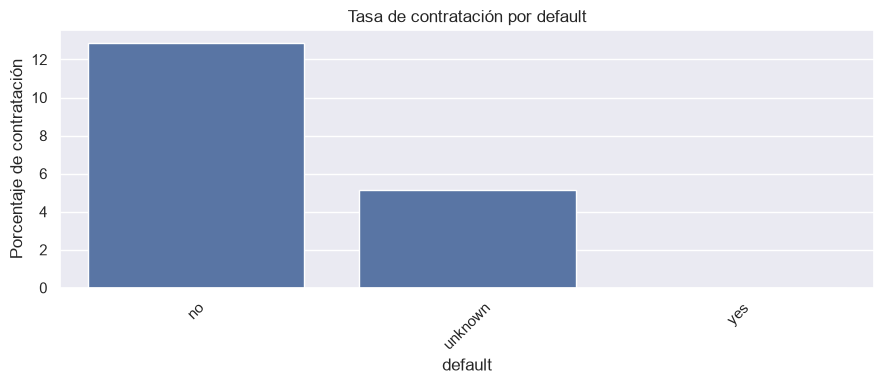

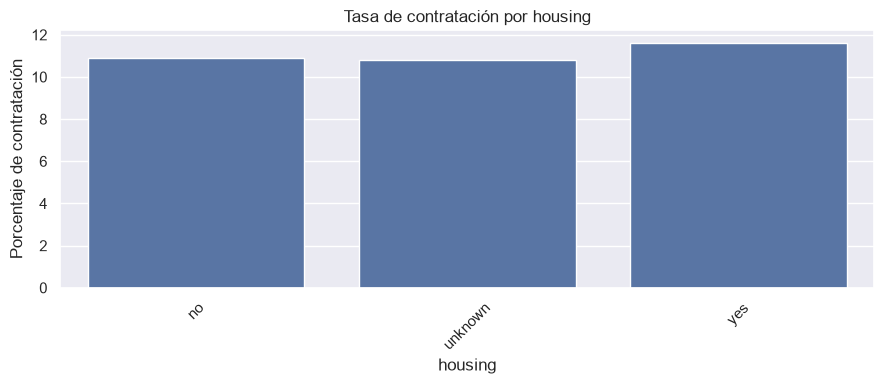

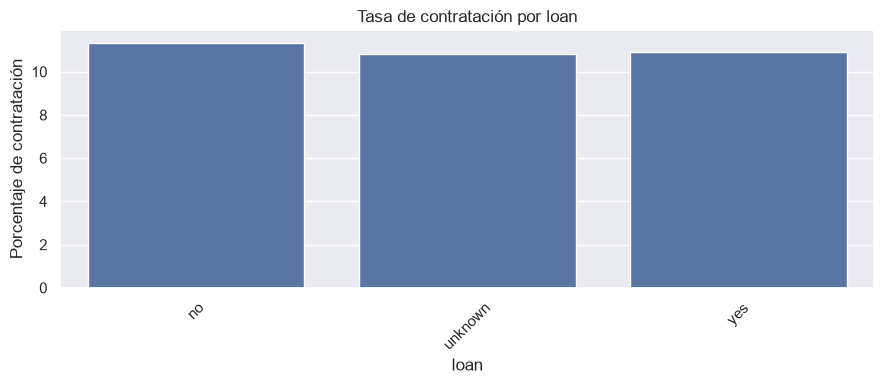

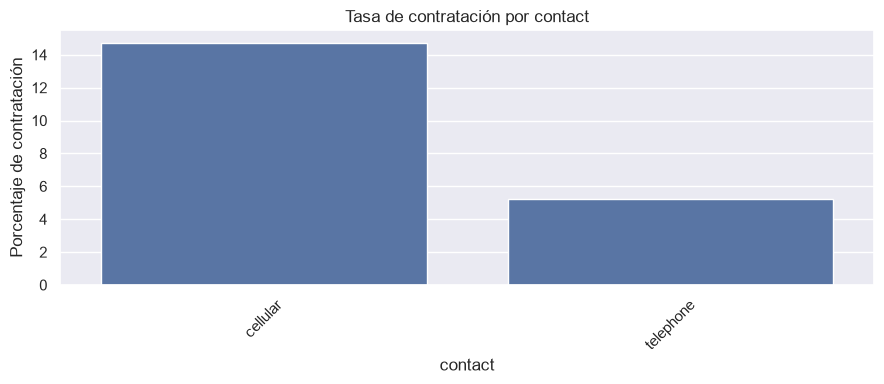

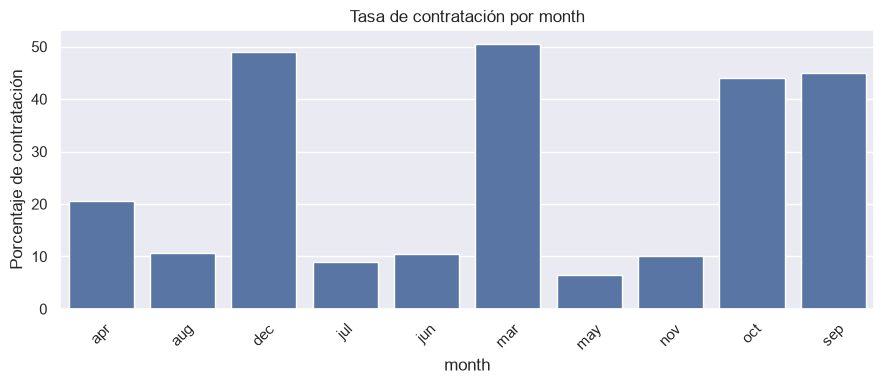

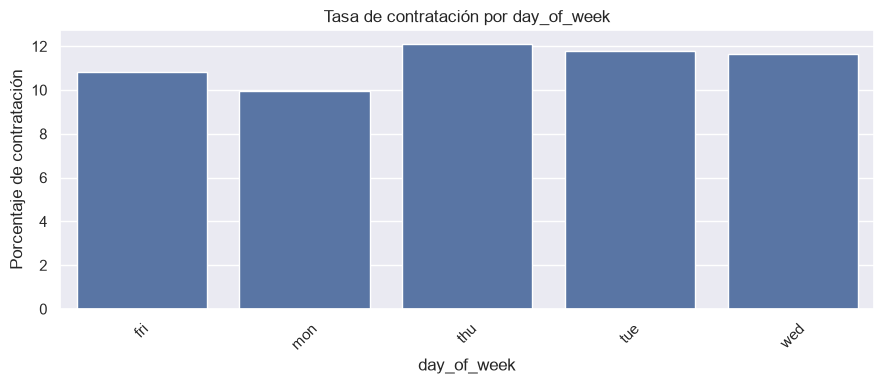

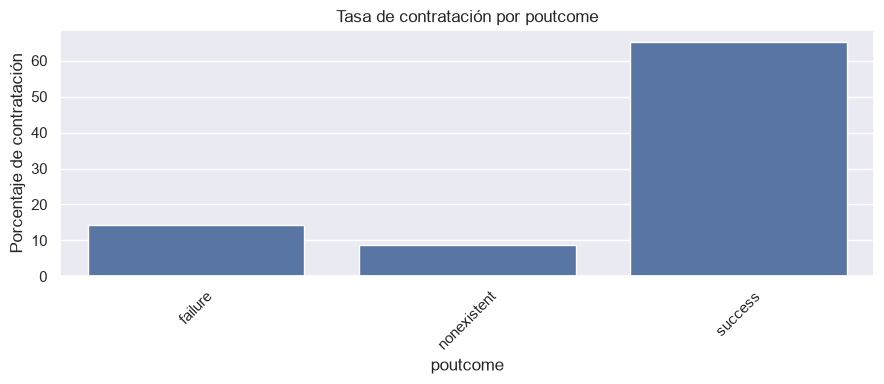

In [28]:
for columna in categorical_columns:

    tasa = (
        df.groupby(columna, as_index=False)["target"]
        .mean()
    )

    tasa["target"] = tasa["target"] * 100

    plt.figure(figsize=(9, 4))

    sns.barplot(
        data=tasa,
        x=columna,
        y="target"
    )

    plt.title(f"Tasa de contratación por {columna}")
    plt.xlabel(columna)
    plt.ylabel("Porcentaje de contratación")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Matriz de correlación

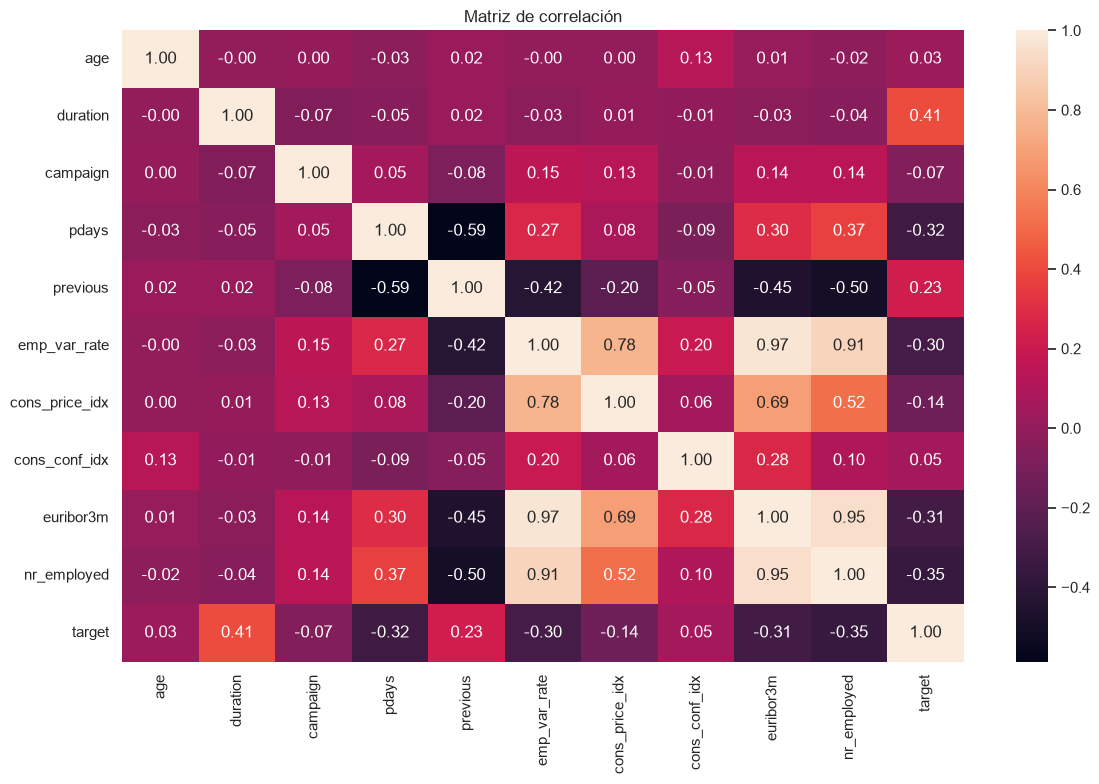

In [29]:
correlation_matrix = df[numerical_columns + ["target"]].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 2.10 Ingeniería de características básica

In [30]:
df["previously_contacted"] = df["pdays"].apply(
    lambda valor: "no" if valor == 999 else "yes"
)

df[["pdays", "previously_contacted"]].head()

,pdays,previously_contacted
0,999,no
1,999,no
2,999,no
3,999,no
4,999,no


### Decisión sobre duration

duration se eliminará del modelo principal porque la duración de una llamada solo se conoce cuando el contacto ya terminó. Si el banco quiere decidir a quién llamar antes de realizar la llamada, esta variable no estaría disponible.

## 2.11 División en train y test

In [31]:
X = df.drop(
    columns=[
        "y",
        "target",
        "duration"
    ]
)

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (32940, 20)
Test: (8236, 20)


## 2.12 Preprocesamiento

In [32]:
numeric_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['age', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'previously_contacted']


In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

# Paso 3: Modelo de Regresión Logística

Regresión logística sencilla, sin optimizar hiperparámetros.

In [34]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [35]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(
    X_test
)[:, 1]

## Evaluación del modelo inicial

In [36]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No contrata",
            "Sí contrata"
        ]
    )
)

              precision    recall  f1-score   support

 No contrata       0.91      0.99      0.95      7308
 Sí contrata       0.65      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.63      8236
weighted avg       0.88      0.90      0.87      8236



In [37]:
initial_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        y_probability
    )
})

initial_metrics

accuracy     0.898373
precision    0.652174
recall       0.210129
f1           0.317848
roc_auc      0.800290
dtype: float64

## Matriz de confusión

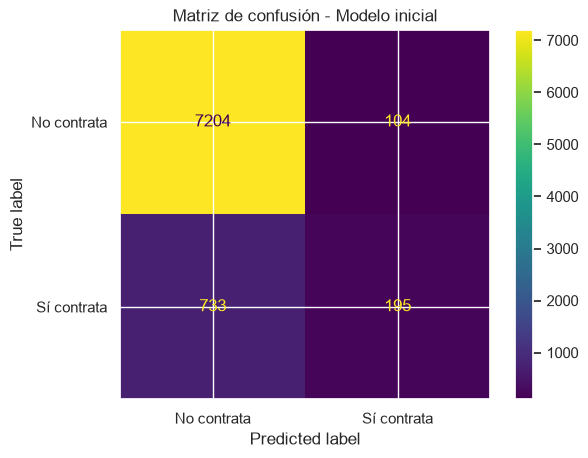

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No contrata",
        "Sí contrata"
    ]
)

plt.title("Matriz de confusión - Modelo inicial")
plt.show()

## Curva ROC

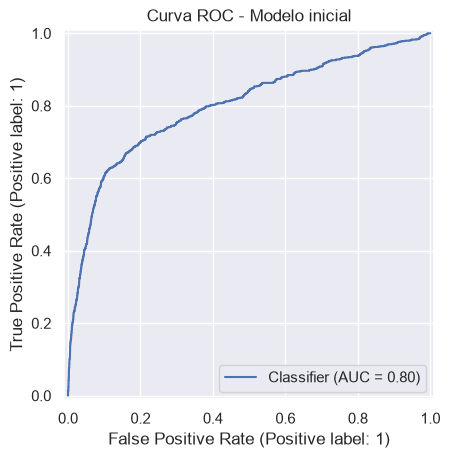

In [39]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("Curva ROC - Modelo inicial")
plt.show()

# Paso 4: Optimización básica

Se utilizarán dos mejoras sencillas:

1. `class_weight='balanced'`
2. `GridSearchCV` con pocos valores de `C`

## 4.1 Modelo balanceado

In [40]:
balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)
balanced_probability = balanced_model.predict_proba(
    X_test
)[:, 1]

In [41]:
balanced_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_test,
        balanced_pred
    ),
    "precision": precision_score(
        y_test,
        balanced_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        balanced_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        balanced_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        balanced_probability
    )
})

balanced_metrics

accuracy     0.830379
precision    0.359328
recall       0.645474
f1           0.461657
roc_auc      0.800222
dtype: float64

## 4.2 GridSearchCV

In [42]:
parameter_grid = {
    "classifier__C": [
        0.1,
        1,
        10
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor F1 en validación:")
print(grid_search.best_score_)

Mejores parámetros:
{'classifier__C': 10, 'classifier__class_weight': 'balanced'}

Mejor F1 en validación:
0.4519342518609874


## Evaluación del modelo optimizado

In [43]:
optimized_model = grid_search.best_estimator_

optimized_pred = optimized_model.predict(
    X_test
)

optimized_probability = optimized_model.predict_proba(
    X_test
)[:, 1]

optimized_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_test,
        optimized_pred
    ),
    "precision": precision_score(
        y_test,
        optimized_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        optimized_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        optimized_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        optimized_probability
    )
})

optimized_metrics

accuracy     0.830500
precision    0.359544
recall       0.645474
f1           0.461835
roc_auc      0.800225
dtype: float64

## Comparación final

In [44]:
comparison = pd.DataFrame({
    "Modelo inicial": initial_metrics,
    "Modelo balanceado": balanced_metrics,
    "Modelo optimizado": optimized_metrics
}).T

comparison

,accuracy,precision,recall,f1,roc_auc
Modelo inicial,0.898373,0.652174,0.210129,0.317848,0.800290
Modelo balanceado,0.830379,0.359328,0.645474,0.461657,0.800222
Modelo optimizado,0.830500,0.359544,0.645474,0.461835,0.800225


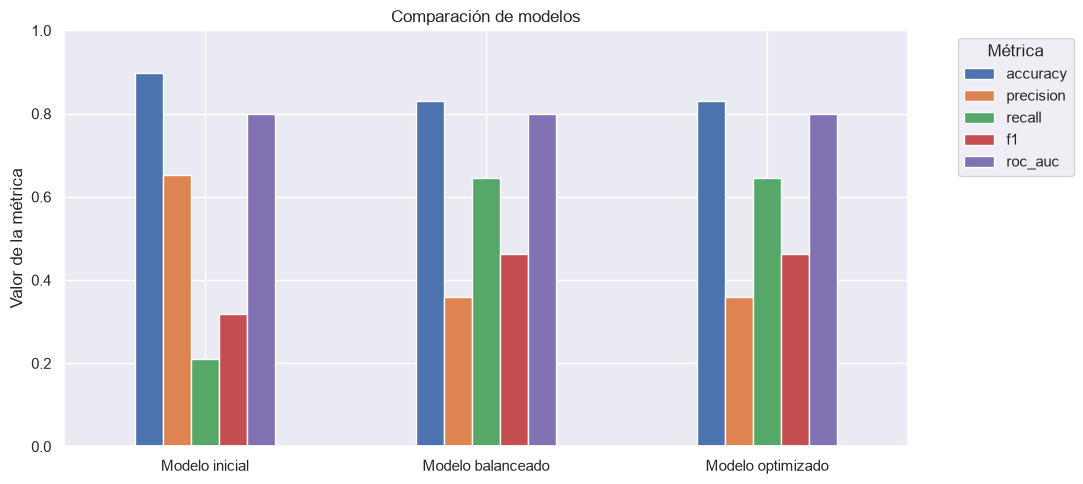

In [45]:
comparison.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Comparación de modelos")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.05, 1)
)
plt.tight_layout()
plt.show()

# Conclusiones

El análisis permitió identificar que el problema corresponde a una clasificación con una variable objetivo desbalanceada, ya que la mayoría de los clientes no contrata el depósito. El EDA ayudó a revisar la calidad de los datos, detectar duplicados, valores unknown, distribuciones sesgadas y posibles valores extremos, así como a comparar variables numéricas y categóricas con la respuesta del cliente. También se observó que algunas variables de campaña y contexto económico pueden aportar información útil para distinguir a los clientes con mayor probabilidad de contratación. Para el modelado se utilizó una regresión logística como enfoque inicial por su sencillez e interpretabilidad, y posteriormente se probó una versión balanceada y una optimización básica. La evaluación debe centrarse no solo en accuracy, sino también en precision, recall, F1 y ROC-AUC, especialmente porque para el banco es importante identificar correctamente a los clientes con mayor probabilidad de contratar y reducir esfuerzos de marketing poco efectivos.